# Arten von Concept Drift — Phänomen-Illustration

Erzeugt die schematischen Beispielsignale der vier Drift-Arten (Sudden, Incremental,
Gradual, Recurring) sowie der Abgrenzungsfälle (Ausreißer, Rauschen) und speichert je
ein `.pgf` unter `plots/phenomenon_*` für Kapitel 2. Reine Illustration — kein
Datenpipeline-Schritt, daher kein Cache/Ledger; Style, Pfade, Seed und Speichern folgen
aber konsistent *syn_generation*.

In [67]:
IS_FINAL = True   

SEED     = 42

In [68]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, ".."))

base_dir    = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
plot_dir    = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts
from src.utils import run_registry as rr

rng = np.random.default_rng(SEED)

fig_cfg    = rr.RunConfig({"seed": SEED, "figure": "kinds_of_concept_drift"})
plot_store = rr.OutputStore(plot_dir, "phenomenon")

## Definition der Phänomene

In [70]:
time = np.arange(0, 21)          # ganzzahliges Raster 0..20 -> Umschaltpunkte fallen exakt auf Samples

# Systematische Concept-Drift-Arten
sudden      = np.where(time < 10, 0, 1)
incremental = np.clip((time - 6) / 4, 0, 1)

gradual = np.zeros_like(time)
change_points = [0, 5, 6, 9, 12, 15, 21]   # Umschaltpunkte
for i in range(len(change_points) - 1):
    gradual[(time >= change_points[i]) & (time < change_points[i + 1])] = i % 2

recurring = np.zeros_like(time)
recurring[(time >= 7) & (time < 15)] = 1

# Abzugrenzen: Einzelausreißer und statistisches Rauschen
outlier = np.zeros_like(time)
outlier[12] = 1

noise = rng.random(len(time))

phenomena = [
    (sudden,      "sudden_drift",      "drift_afflicted"),
    (incremental, "incremental_drift", "drift_afflicted"),
    (gradual,     "gradual_drift",     "drift_afflicted"),
    (recurring,   "recurring_drift",   "drift_afflicted"),
    (outlier,     "outlier",           "noise"),
    (noise,       "noise",             "noise"),
]

## Einzelplots für die Thesis

Je Phänomen eine quadratische Teilabbildung; Speichern über den `plot_store`
(stabiles `.pgf` + PNG-Archiv, `final=IS_FINAL`).

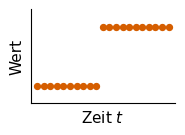

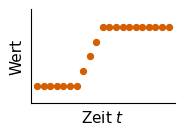

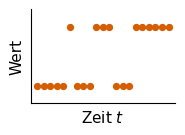

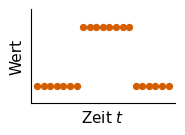

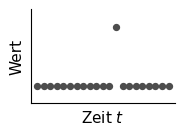

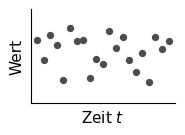

In [71]:
SUBFIG_SCALE = 1 / 3.2   # sechs Teilabbildungen nebeneinander -> ~Drittel-Textbreite

for signal, name, role in phenomena:
    w = ts.fig_width(SUBFIG_SCALE)
    fig, ax = plt.subplots(figsize=(w, w * 0.75))
    ax.scatter(time, signal, **ts.scatter(role, s=18))
    ax.set_ylim(-0.3, 1.3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, alpha=0.25)
    ax.set_xlabel("Zeit $t$")
    ax.set_ylabel("Wert")
    fig.tight_layout()
    plot_store.save_figure(fig, name, fig_cfg, final=IS_FINAL)